# Portfolio Risk Analysis: Integrated Oil & Gas

## Project Overview

This project uses Python to analyze the downside risk of a portfolio consisting of major Integrated Oil & Gas companies through three key risk-management techniques:

- **[Value at Risk (VaR)](https://www.investopedia.com/terms/v/var.asp):** Estimates the maximum expected loss over a specific period at a given confidence level. For example, a 95% daily VaR of -2% indicates that there is a 5% chance the portfolio could lose more than 2% in a single day (Investopedia, 2026).

- **[Conditional Value at Risk (CVaR)](https://www.investopedia.com/terms/c/conditional_value_at_risk.asp):** Measures the average loss when losses exceed the VaR threshold. CVaR therefore provides insight into the severity of losses during extreme market conditions (Investopedia, 2026).

- **[Stress Testing](https://www.investopedia.com/terms/s/stresstesting.asp):** Evaluates how the portfolio might perform under extreme market scenarios, such as a major stock-market decline or an energy-sector shock (Investopedia, 2025).

Given the current geopolitical situation in the Middle East and global macroeconomic uncertainty, energy companies are exposed to significant market volatility and may face heightened exposure to changes in energy prices, supply disruptions, inflation, interest rates, and global demand. These macroeconomic and geopolitical risk factors make the energy sector particularly relevant for analyzing downside risk through Value at Risk (VaR), Conditional Value at Risk (CVaR), and stress testing.

Using historical stock-price data, this project aims to measure and visualize the potential losses of an equally weighted portfolio containing **Exxon Mobil (XOM), Chevron (CVX), Shell (SHEL), BP (BP), and TotalEnergies (TTE)**.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define stocks and time period
tickers = ['XOM', 'CVX', 'SHEL', 'BP', 'TTE']
start_date = '2023-01-01'
end_date = '2026-08-07'

In [3]:
# Fetch adjusted closing prices
data = yf.download(tickers, start=start_date, end=end_date)['Close']
data = yf.download(
    tickers,
    start=start_date,
    end=end_date
)['Close']

data.head()

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed


Ticker,BP,CVX,SHEL,TTE,XOM
Date,,,,,
2023-01-03,28.616453,150.522659,48.722385,51.583519,94.790810
2023-01-04,28.166199,148.922134,48.243687,51.281277,95.066704
2023-01-05,28.266258,151.604034,48.287201,51.306461,97.193718
2023-01-06,28.733194,152.745956,49.827721,51.910965,98.368484
2023-01-09,28.991674,151.552109,50.541420,52.246784,96.535156


In [4]:
# Calculate daily returns
returns = data.pct_change().dropna()

In [5]:
# Assume equal weights (1/3 each)
weights = np.array([1/len(tickers)] * len(tickers))

In [6]:
# Calculate portfolio daily returns
portfolio_returns = returns.dot(weights)

In [7]:
# Step 1: Calculate VaR at 95% confidence
var_95 = np.percentile(portfolio_returns, 5)
print(f"Daily VaR (95% Confidence): {var_95:.2%}")

# Step 2: Calculate CVaR
cvar = portfolio_returns[portfolio_returns <= var_95].mean()
print(f"Daily CVaR (Tail Risk): {cvar:.2%}")

# Step 3: Stress test with a 20% drop
stressed_returns = portfolio_returns - 0.20
print(f"Average Daily Return After 20% Stress Test: {stressed_returns.mean():.2%}")

Daily VaR (95% Confidence): -2.10%
Daily CVaR (Tail Risk): -3.03%
Average Daily Return After 20% Stress Test: -19.94%


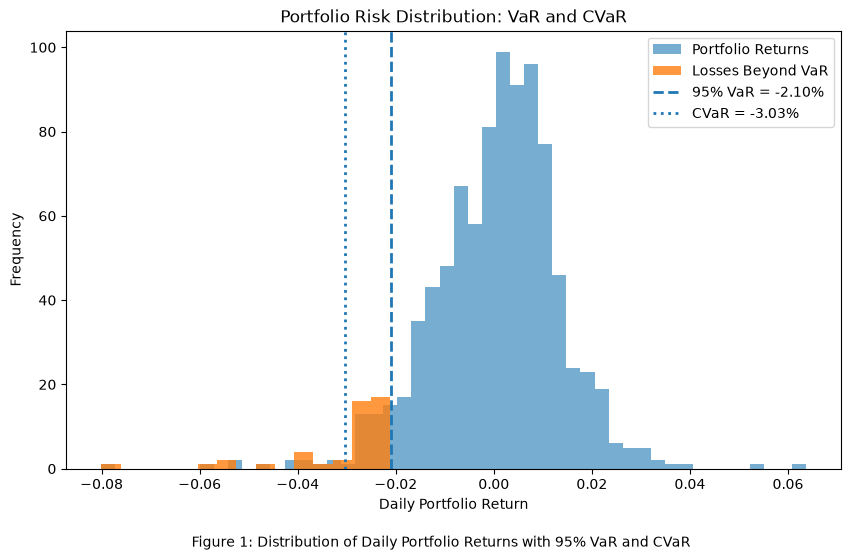

In [8]:
# Plot distribution of portfolio daily returns
plt.figure(figsize=(10, 6))

# Full return distribution
plt.hist(
    portfolio_returns,
    bins=50,
    alpha=0.6,
    label='Portfolio Returns'
)

# Highlight returns worse than VaR
tail_losses = portfolio_returns[portfolio_returns <= var_95]

plt.hist(
    tail_losses,
    bins=15,
    alpha=0.8,
    label='Losses Beyond VaR'
)

# VaR threshold
plt.axvline(
    var_95,
    linestyle='--',
    linewidth=2,
    label=f'95% VaR = {var_95:.2%}'
)

# CVaR
plt.axvline(
    cvar,
    linestyle=':',
    linewidth=2,
    label=f'CVaR = {cvar:.2%}'
)

plt.title('Portfolio Risk Distribution: VaR and CVaR')
plt.xlabel('Daily Portfolio Return')
plt.ylabel('Frequency')

# Make room for caption
plt.subplots_adjust(bottom=0.15)

# Figure caption
plt.figtext(
    0.5,
    0.02,
    'Figure 1: Distribution of Daily Portfolio Returns with 95% VaR and CVaR',
    ha='center',
    fontsize=10
)

plt.legend()
plt.show()

## Stress Testing

Stress testing evaluates how a portfolio might perform under an extreme but plausible market event. Unlike VaR and CVaR, which estimate risk using the distribution of historical returns, stress testing applies a hypothetical shock directly to the portfolio (Investopedia, 2025)

For this analysis, we assume an initial portfolio value of **$100,000** and simulate a **20% decline in portfolio value**.

The stress scenario allows us to estimate:
- The dollar loss caused by the market shock.
- The remaining portfolio value after the shock.
- The portfolio's exposure to a severe market downturn.

A 20% decline represents a significant adverse scenario and provides a simple way to evaluate the potential financial impact of an extreme market event.

In [9]:
initial_portfolio_value = 100000

# Assume a 20% decline in portfolio value
stress_loss = initial_portfolio_value * 0.20

# Calculate portfolio value after the stress event
stressed_portfolio_value = initial_portfolio_value - stress_loss

print(f"Initial Portfolio Value: ${initial_portfolio_value:,.2f}")
print(f"Loss Under 20% Stress Scenario: ${stress_loss:,.2f}")
print(f"Portfolio Value After Stress: ${stressed_portfolio_value:,.2f}")

Initial Portfolio Value: $100,000.00
Loss Under 20% Stress Scenario: $20,000.00
Portfolio Value After Stress: $80,000.00


### Stress Test Visualization

The chart below compares the portfolio's **initial value** with its value after applying a hypothetical **20% market shock**. Since we are starting with a portfolio value of **$100,000**, the stress scenario produces a loss of **$20,000**, reducing the portfolio value to **$80,000**. Through this visualization, we will have a clear representation of the potential financial impact of a severe market downturn on the portfolio.

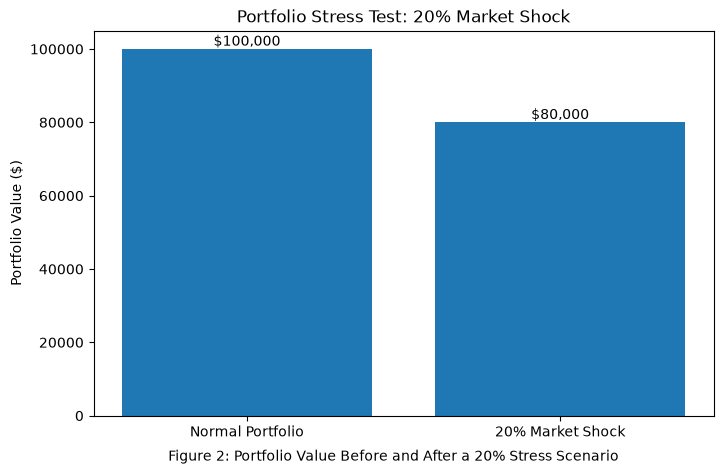

In [10]:
# Define portfolio values and labels
values = [
    initial_portfolio_value,
    stressed_portfolio_value
]

labels = [
    'Normal Portfolio',
    '20% Market Shock'
]

# Create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

# Add portfolio values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title('Portfolio Stress Test: 20% Market Shock')
plt.ylabel('Portfolio Value ($)')

# Figure caption
plt.figtext(
    0.5,
    0.02,
    'Figure 2: Portfolio Value Before and After a 20% Stress Scenario',
    ha='center',
    fontsize=10
)

plt.show()

## Overall Assessment
Ultimately, this project demonstrates how we can utilize Python and historical financial data to transform and visualize stock-price movements into practical measures of portfolio risk management, especially when exposed to adverse market events. This allows us to bring all the info one needs to make decisions to manage different market scenarios that will affect portfolio performance.

The historical risk analysis produced a **95% daily VaR of approximately -2.10%**. Based on the historical return distribution used in the analysis, we can see how approximately 5% of observed trading days experienced portfolio losses greater than 2.10%.

As shown in **Figure 1**, the VaR threshold marks the beginning of the left tail of the portfolio's historical return distribution. The observations highlighted beyond this threshold represent the portfolio's most severe historical daily losses. However, VaR alone provides an incomplete picture of downside risk. While VaR identifies the threshold at which the most severe 5% of historical losses begin, it does not indicate how large those losses can become once the threshold is exceeded.

This limitation becomes clearer when considering the portfolio's **CVaR of approximately -3.03%**. CVaR indicates that among the historical observations in which losses exceeded the 2.10% VaR threshold, the **average loss was approximately 3.03%**. Looking closely at Figure 1 demonstrates that some individual historical losses extended considerably further into the left tail, which shows to us that extreme losses can be substantially larger than the VaR threshold.

To complement these historical risk measures, **Figure 2** presents a hypothetical stress test using an initial portfolio value of **$100,000**. Under this assumed  **20% adverse shock**, the portfolio would experience a **$20,000 loss**, reducing its value from **$100,000** to **$80,000**. Unlike the VaR and CVaR, this stress scenario does not estimate the probability of such a loss occurring. Instead, this demonstrates how a potential financial impact on the portfolio can become a severe adverse event were it to occur.

This difference between VaR and CVaR stresses the importance of considering **tail risk** since a global conflict such as the **2026 Iran war** disrupts global energy markets, increases oil-price volatility, and produces extreme movements in energy equities. The return distribution also showed that some historical losses extended substantially beyond both the VaR and CVaR estimates. 

Through this portfolio risk analysis, we can utilize Python to illustrate why **VaR should not be relied upon as a standalone measure of portfolio risk**, particularly in a sector that is sensitive to commodity-price movements, economic conditions, supply disruptions, and geopolitical events. With this ind mind, investors can use these measures to develop a broader understanding of a portfolio’s exposure to both expected and extreme downside risk, allowing them to make more informed decisions regarding portfolio construction, diversification, and risk management.

## References
Aroussi, R. (2025). *yfinance documentation.* https://ranaroussi.github.io/yfinance/

Investopedia. (2026a, July). *Conditional value at risk (CVaR).* https://www.investopedia.com/terms/c/conditional_value_at_risk.asp

Investopedia. (2025, September). *Stress testing.* https://www.investopedia.com/terms/s/stresstesting.asp

Investopedia. (2026b, March). *Value at risk (VaR).* https://www.investopedia.com/terms/v/var.asp

Jose. (2025, March 2). *3. Risk management techniques with Python and real-world data*. Finance Hub. https://pythonandfinancehub.com/3-risk-management-techniques-with-python-and-real-world-data/